# Drift Detection Visualizations

## Purpose
Comprehensive visualizations showcasing data drift detection results using multiple statistical and graphical approaches.

## Contents
- Distribution comparison (KDE plots, violin plots)
- Drift metrics heatmaps
- Numeric vs categorical feature analysis
- Edge case testing
- Performance benchmarking
- Summary comparisons

## Setup: Load Data from Main Drift Detection Notebook

First, run the main drift detection notebook (02_drift_detection.ipynb) to set up all the data and run the core drift detection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import gaussian_kde, wasserstein_distance
import json
import time
import sys
import warnings
warnings.filterwarnings('ignore')

print("Visualization libraries loaded successfully!")

Visualization libraries loaded successfully!


In [4]:
# Load training statistics and initialize drift detector
with open('../data/processed/training_reference_stats.json', 'r') as f:
    training_stats = json.load(f)

sys.path.insert(0, '../src')
from drift_detector import DriftDetector

detector = DriftDetector(training_stats)
print("Drift detector initialized!")

# Load test data
baseline_df = pd.read_csv('../data/user_testing/baseline_large.csv')
drifted_df = pd.read_csv('../data/user_testing/drifted_data.csv')

print(f"Baseline data: {len(baseline_df)} samples")
print(f"Drifted data: {len(drifted_df)} samples")

Drift detector initialized!
Baseline data: 500 samples
Drifted data: 10 samples


In [5]:
# Run drift detection
baseline_report = detector.detect_drift(baseline_df)
drifted_report = detector.detect_drift(drifted_df)

print("Baseline Report:")
print(f"  Status: {baseline_report['overall_status']}")
print(f"  High Severity Features: {baseline_report['summary']['high_severity']}")

print("\nDrifted Report:")
print(f"  Status: {drifted_report['overall_status']}")
print(f"  High Severity Features: {drifted_report['summary']['high_severity']}")

Baseline Report:
  Status: OK
  High Severity Features: 0

Drifted Report:
  Status: CRITICAL
  High Severity Features: 10


---
# 1. DISTRIBUTION DRIFT ANALYSIS: KDE + VIOLIN + HEATMAP

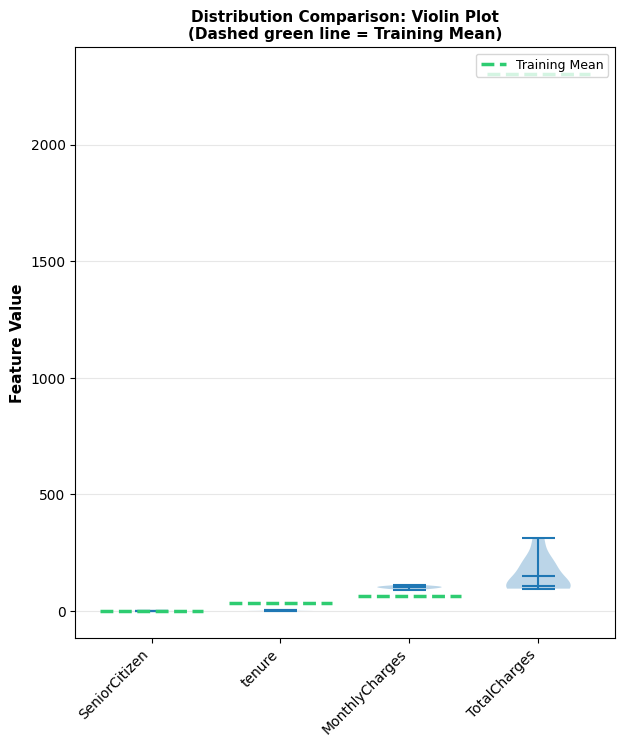

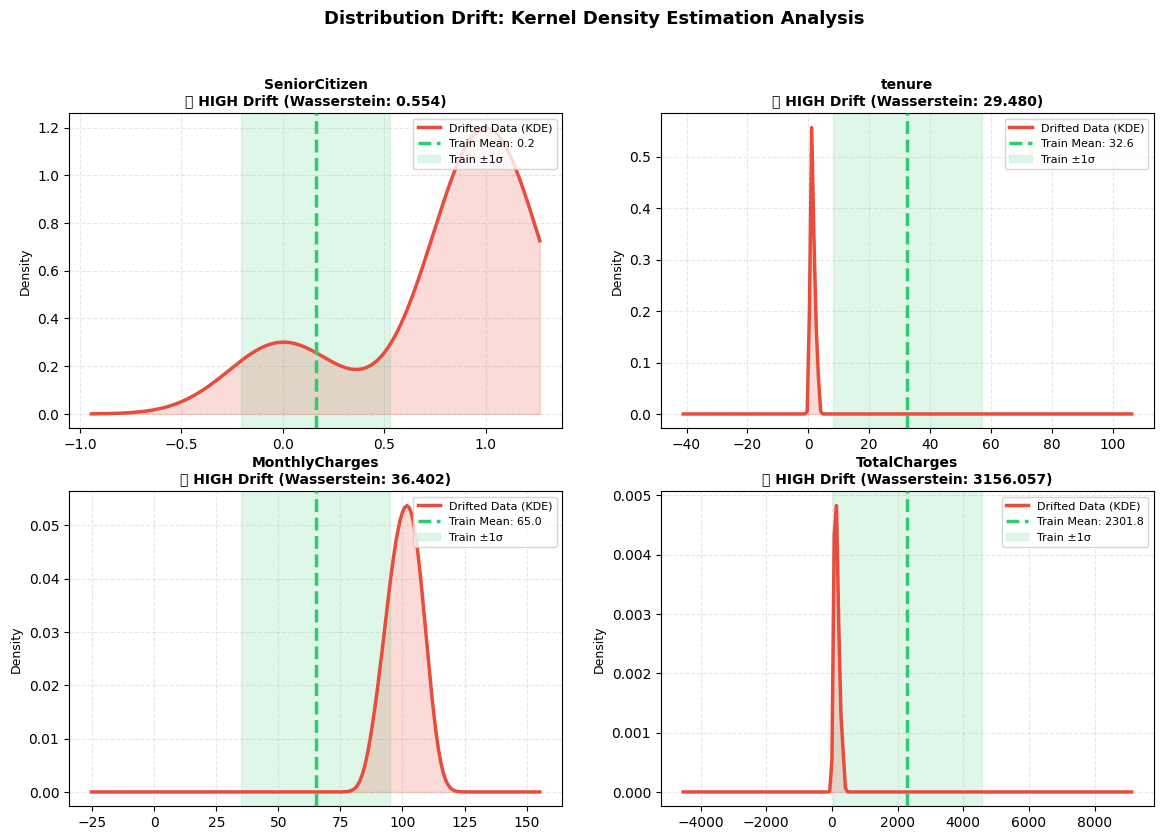

✅ KDE plots generated successfully!


In [6]:
# Extract numeric features
numeric_features_list = list(training_stats['numeric_features'].keys())
n_features = len(numeric_features_list)

# Create combination of visualizations
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# ============================================================================
# 1. VIOLIN PLOTS - Show distribution of drifted data vs training mean
# ============================================================================
ax1 = fig.add_subplot(gs[0:2, 0])

violin_data = []
x_labels = []
for feature in numeric_features_list:
    violin_data.append(drifted_df[feature].values)
    x_labels.append(feature)

parts = ax1.violinplot(violin_data, positions=range(len(numeric_features_list)), 
                       showmeans=True, showmedians=True)

# Add training means as horizontal lines
for idx, feature in enumerate(numeric_features_list):
    train_mean = training_stats['numeric_features'][feature]['mean']
    ax1.hlines(train_mean, idx - 0.4, idx + 0.4, colors='#2ecc71', linewidth=2.5, 
              linestyles='--', label='Training Mean' if idx == 0 else '')

ax1.set_xticks(range(len(numeric_features_list)))
ax1.set_xticklabels(x_labels, rotation=45, ha='right')
ax1.set_ylabel('Feature Value', fontweight='bold', fontsize=11)
ax1.set_title('Distribution Comparison: Violin Plot\n(Dashed green line = Training Mean)', 
             fontweight='bold', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend(fontsize=9)

# ============================================================================
# 2. KDE DENSITY PLOTS - For each numeric feature
# ============================================================================
fig_kde, axes_kde = plt.subplots(2, 2, figsize=(14, 9))
axes_kde = axes_kde.flatten()

drift_metrics = []

for idx, feature in enumerate(numeric_features_list):
    ax = axes_kde[idx]
    
    # Drifted data
    drift_data = drifted_df[feature].dropna().values
    
    # Training distribution (reconstructed from stats)
    train_mean = training_stats['numeric_features'][feature]['mean']
    train_std = training_stats['numeric_features'][feature]['std']
    
    if len(drift_data) > 1:
        # KDE for drifted data
        kde_drift = gaussian_kde(drift_data)
        
        # Generate smooth curves
        x_min = min(drift_data.min(), train_mean - 3*train_std)
        x_max = max(drift_data.max(), train_mean + 3*train_std)
        x_range = np.linspace(x_min, x_max, 200)
        
        density_drift = kde_drift(x_range)
        
        # Plot KDE
        ax.plot(x_range, density_drift, linewidth=2.5, label='Drifted Data (KDE)', 
               color='#e74c3c', zorder=3)
        
        # Shade the drifted distribution
        ax.fill_between(x_range, density_drift, alpha=0.2, color='#e74c3c', zorder=2)
        
        # Add training mean and std as reference
        ax.axvline(train_mean, color='#2ecc71', linewidth=2.5, linestyle='--', 
                  label=f'Train Mean: {train_mean:.1f}', zorder=3)
        ax.axvspan(train_mean - train_std, train_mean + train_std, 
                  alpha=0.15, color='#2ecc71', label='Train ±1σ', zorder=1)
        
        # Calculate Wasserstein distance
        synthetic_train = np.random.normal(train_mean, train_std, len(drift_data))
        wasserstein_dist = wasserstein_distance(synthetic_train, drift_data)
        
        # Calculate mean and std shift
        mean_shift = abs(np.mean(drift_data) - train_mean)
        std_ratio = np.std(drift_data) / train_std if train_std > 0 else 1.0
        
        drift_metrics.append({
            'Feature': feature,
            'Wasserstein': wasserstein_dist,
            'Mean Shift': mean_shift,
            'Std Ratio': std_ratio,
            'Drift Mean': np.mean(drift_data),
            'Drift Std': np.std(drift_data)
        })
        
        # Title with metrics
        severity = '🚨 HIGH' if wasserstein_dist > 0.5 else ('⚠️ MED' if wasserstein_dist > 0.2 else '✓ LOW')
        ax.set_title(f'{feature}\n{severity} Drift (Wasserstein: {wasserstein_dist:.3f})', 
                    fontweight='bold', fontsize=10)
        ax.set_ylabel('Density', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Distribution Drift: Kernel Density Estimation Analysis', 
             fontsize=13, fontweight='bold', y=0.995)
plt.show()

print("✅ KDE plots generated successfully!")

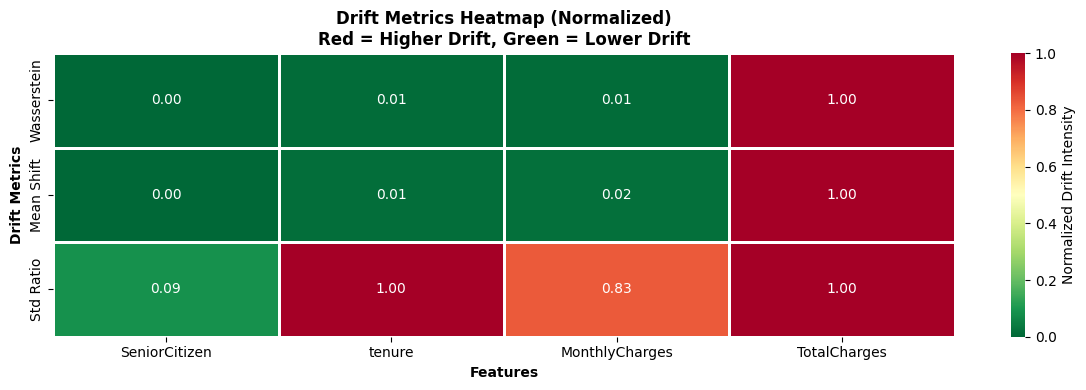

✅ Heatmap generated successfully!


In [7]:
# ============================================================================
# 3. DRIFT METRICS HEATMAP
# ============================================================================
fig_heatmap, ax_heat = plt.subplots(figsize=(12, 4))

# Create metrics dataframe for heatmap
metrics_df = pd.DataFrame(drift_metrics).set_index('Feature')

# Normalize metrics for heatmap (0-1 scale)
metrics_normalized = metrics_df.copy()
metrics_normalized['Wasserstein'] = metrics_normalized['Wasserstein'] / metrics_normalized['Wasserstein'].max()
metrics_normalized['Mean Shift'] = metrics_normalized['Mean Shift'] / metrics_normalized['Mean Shift'].max()
metrics_normalized['Std Ratio'] = abs(metrics_normalized['Std Ratio'] - 1) / max(
    abs(metrics_normalized['Std Ratio'] - 1).max(), 0.1)

# Create heatmap
sns.heatmap(metrics_normalized[['Wasserstein', 'Mean Shift', 'Std Ratio']].T, 
           annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Normalized Drift Intensity'},
           linewidths=1, linecolor='white', ax=ax_heat, vmin=0, vmax=1)
ax_heat.set_title('Drift Metrics Heatmap (Normalized)\nRed = Higher Drift, Green = Lower Drift', 
                 fontweight='bold', fontsize=12)
ax_heat.set_xlabel('Features', fontweight='bold')
ax_heat.set_ylabel('Drift Metrics', fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Heatmap generated successfully!")

In [8]:
# ============================================================================
# 4. Print detailed metrics summary
# ============================================================================
print("\n" + "=" * 110)
print("ADVANCED DISTRIBUTION DRIFT ANALYSIS (Drifted vs Training Data)")
print("=" * 110)
print(f"{'Feature':<20} {'Wasserstein Dist':>18} {'Mean Shift':>15} {'Std Ratio':>15} {'Drift Mean':>15} {'Drift Std':>12}")
print("-" * 110)

for idx, metric in enumerate(drift_metrics):
    print(f"{metric['Feature']:<20} {metric['Wasserstein']:>18.4f} {metric['Mean Shift']:>15.2f} "
          f"{metric['Std Ratio']:>15.3f} {metric['Drift Mean']:>15.2f} {metric['Drift Std']:>12.2f}")

print("-" * 110)

avg_wasserstein = np.mean([m['Wasserstein'] for m in drift_metrics])
avg_mean_shift = np.mean([m['Mean Shift'] for m in drift_metrics])

print(f"\nAverage Wasserstein Distance: {avg_wasserstein:.4f}")
print(f"Average Mean Shift: {avg_mean_shift:.2f}")

if avg_wasserstein > 0.5:
    print("🚨 HIGH DRIFT: Significant distribution shifts detected across features!")
elif avg_wasserstein > 0.2:
    print("⚠️  MODERATE DRIFT: Notable distribution changes observed")
else:
    print("✓ LOW DRIFT: Distributions are relatively stable")
    
print("\nMETRIC DEFINITIONS:")
print("  • Wasserstein Distance: Earth mover's distance between distributions (higher = more drift)")
print("  • Mean Shift: Absolute difference between drifted and training means")
print("  • Std Ratio: Ratio of drifted to training standard deviation (1.0 = equal spread)")
print("=" * 110)


ADVANCED DISTRIBUTION DRIFT ANALYSIS (Drifted vs Training Data)
Feature                Wasserstein Dist      Mean Shift       Std Ratio      Drift Mean    Drift Std
--------------------------------------------------------------------------------------------------------------
SeniorCitizen                    0.5537            0.64           1.086            0.80         0.40
tenure                          29.4799           31.06           0.027            1.50         0.67
MonthlyCharges                  36.4024           35.72           0.194          100.72         5.83
TotalCharges                  3156.0573         2150.75           0.030          151.08        69.05
--------------------------------------------------------------------------------------------------------------

Average Wasserstein Distance: 805.6233
Average Mean Shift: 554.54
🚨 HIGH DRIFT: Significant distribution shifts detected across features!

METRIC DEFINITIONS:
  • Wasserstein Distance: Earth mover's distance

---
# 2. NUMERIC FEATURES: Detailed Comparison

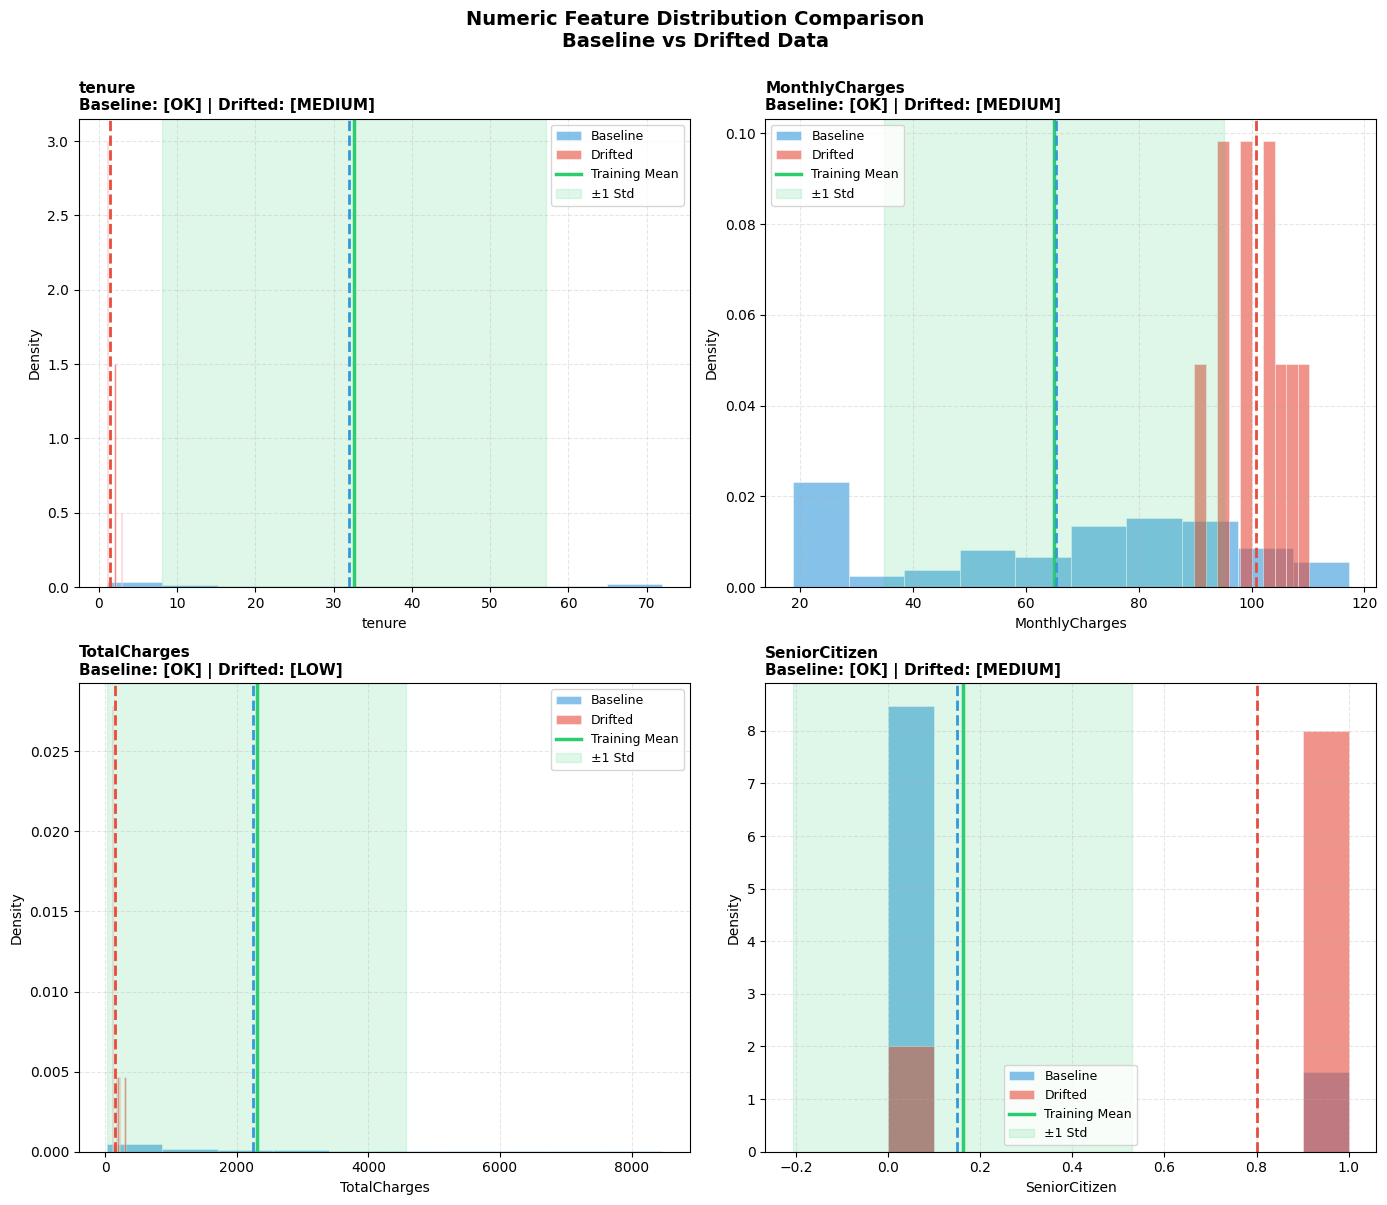

✅ Numeric feature comparison generated!


In [9]:
# Enhanced Numeric Feature Visualization with Z-Score & KS Test Results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

# Color scheme
colors = {
    'baseline': '#3498db',    # Blue
    'drifted': '#e74c3c',     # Red  
    'training': '#2ecc71',    # Green
    'warning': '#f39c12',     # Orange
    'critical': '#c0392b'     # Dark Red
}

for idx, feature in enumerate(numeric_features):
    ax = axes[idx // 2, idx % 2]
    
    # Get training stats
    train_stats = training_stats['numeric_features'][feature]
    train_mean = train_stats['mean']
    train_std = train_stats['std']
    
    # Get drift detection results
    baseline_info = baseline_report['numeric_features'][feature]
    drifted_info = drifted_report['numeric_features'][feature]
    
    # New data values
    baseline_vals = baseline_df[feature].dropna()
    drifted_vals = drifted_df[feature].dropna()
    
    # Plot histograms
    ax.hist(baseline_vals, bins=10, alpha=0.6, label='Baseline', color=colors['baseline'], 
            density=True, edgecolor='white', linewidth=0.5)
    ax.hist(drifted_vals, bins=10, alpha=0.6, label='Drifted', color=colors['drifted'], 
            density=True, edgecolor='white', linewidth=0.5)
    
    # Add training mean and std range
    ax.axvline(train_mean, color=colors['training'], linestyle='-', linewidth=2.5, label='Training Mean')
    ax.axvspan(train_mean - train_std, train_mean + train_std, alpha=0.15, color=colors['training'], label='±1 Std')
    
    # Add new data means
    ax.axvline(baseline_info['new_mean'], color=colors['baseline'], linestyle='--', linewidth=2)
    ax.axvline(drifted_info['new_mean'], color=colors['drifted'], linestyle='--', linewidth=2)
    
    # Build title with statistical info
    baseline_status = "OK" if baseline_info['severity'] == 'LOW' else baseline_info['severity']
    drifted_status = drifted_info['severity']
    
    title = f"{feature}\nBaseline: [{baseline_status}] | Drifted: [{drifted_status}]"
    
    # Color background based on severity
    if drifted_info['severity'] == 'HIGH':
        ax.set_facecolor('#fff5f5')
    
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=9)

plt.suptitle('Numeric Feature Distribution Comparison\nBaseline vs Drifted Data', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✅ Numeric feature comparison generated!")

---
# 3. CATEGORICAL FEATURES: Proportion Analysis

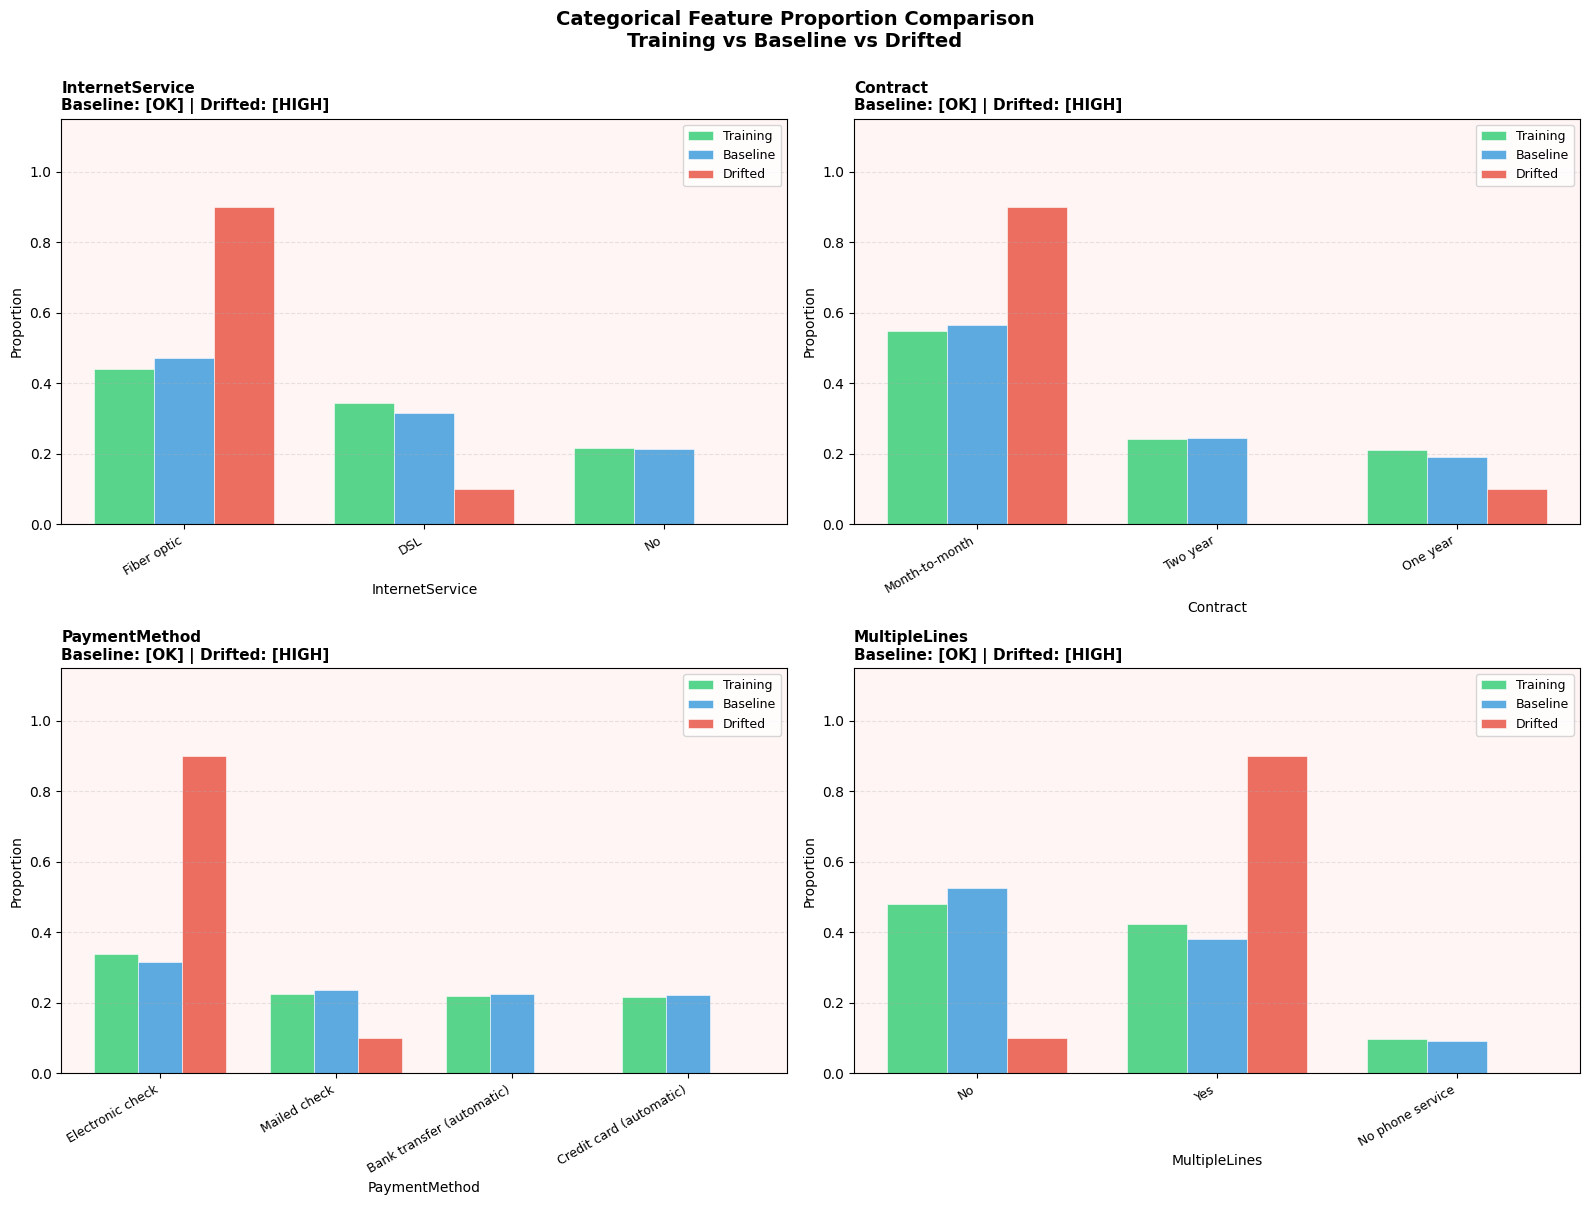

✅ Categorical feature comparison generated!


In [14]:
# Enhanced Categorical Feature Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
categorical_features = ['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines']

for idx, feature in enumerate(categorical_features):
    ax = axes[idx // 2, idx % 2]
    
    # Get training proportions
    train_props = training_stats['categorical_features'][feature]['proportions']
    all_cats = list(train_props.keys())
    
    # Get drift detection results
    baseline_info = baseline_report['categorical_features'][feature]
    drifted_info = drifted_report['categorical_features'][feature]
    
    # Calculate proportions
    baseline_props = baseline_df[feature].value_counts(normalize=True)
    drifted_props = drifted_df[feature].value_counts(normalize=True)
    
    train_vals = [train_props.get(cat, 0) for cat in all_cats]
    baseline_vals = [baseline_props.get(cat, 0) for cat in all_cats]
    drifted_vals = [drifted_props.get(cat, 0) for cat in all_cats]
    
    x = np.arange(len(all_cats))
    width = 0.25
    
    # Create bars
    bars1 = ax.bar(x - width, train_vals, width, label='Training', 
                   color=colors['training'], alpha=0.8, edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(x, baseline_vals, width, label='Baseline', 
                   color=colors['baseline'], alpha=0.8, edgecolor='white', linewidth=0.5)
    bars3 = ax.bar(x + width, drifted_vals, width, label='Drifted', 
                   color=colors['drifted'], alpha=0.8, edgecolor='white', linewidth=0.5)
    
    baseline_status = "OK" if baseline_info['severity'] == 'LOW' else baseline_info['severity']
    drifted_status = drifted_info['severity']
    
    if drifted_info['severity'] == 'HIGH':
        ax.set_facecolor('#fff5f5')
    
    title = f"{feature}\nBaseline: [{baseline_status}] | Drifted: [{drifted_status}]"
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Proportion', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(all_cats, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.legend(fontsize=9)

plt.suptitle('Categorical Feature Proportion Comparison\nTraining vs Baseline vs Drifted', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✅ Categorical feature comparison generated!")

---
# 4. OVERALL SUMMARY: Drift Severity Heatmap

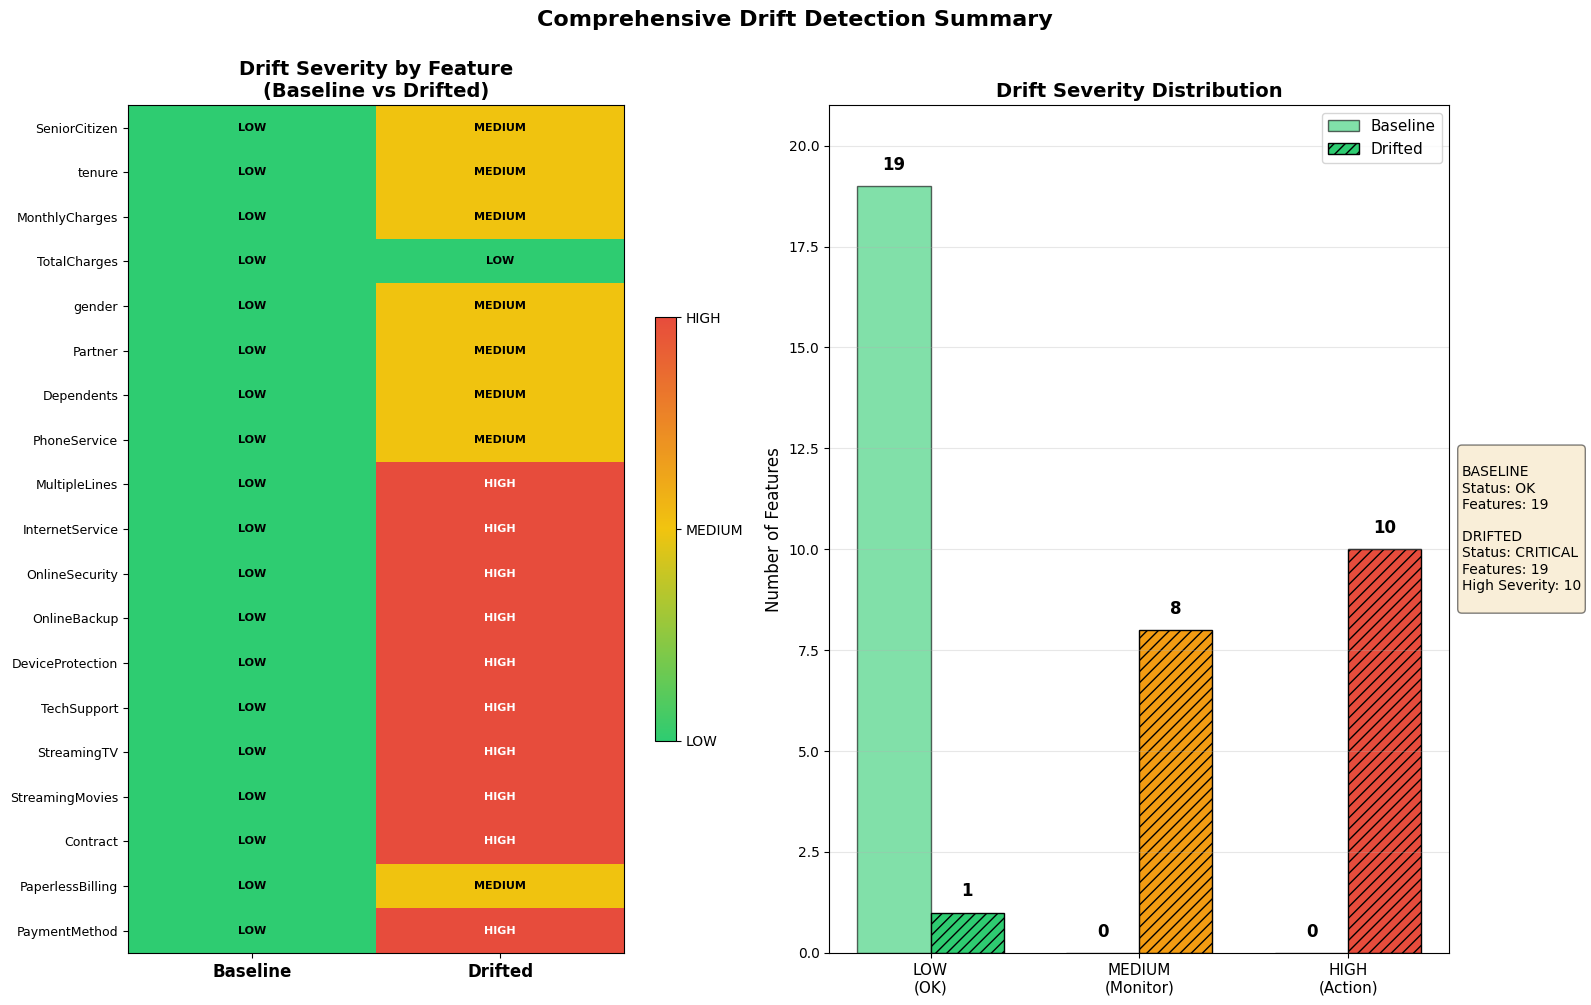

✅ Summary heatmap generated!


In [11]:
# Create comprehensive drift summary heatmap

# Collect all features and their severity scores
all_features = list(baseline_report['numeric_features'].keys()) + list(baseline_report['categorical_features'].keys())

# Map severity to numeric values
severity_map = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}

baseline_severities = []
drifted_severities = []

for feature in all_features:
    if feature in baseline_report['numeric_features']:
        baseline_severities.append(severity_map[baseline_report['numeric_features'][feature]['severity']])
        drifted_severities.append(severity_map[drifted_report['numeric_features'][feature]['severity']])
    else:
        baseline_severities.append(severity_map[baseline_report['categorical_features'][feature]['severity']])
        drifted_severities.append(severity_map[drifted_report['categorical_features'][feature]['severity']])

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Custom colormap
cmap = mcolors.LinearSegmentedColormap.from_list('drift', ['#2ecc71', '#f1c40f', '#e74c3c'])

# Prepare data for heatmap
data = np.array([baseline_severities, drifted_severities]).T

# Create heatmap
im = axes[0].imshow(data, cmap=cmap, aspect='auto', vmin=0, vmax=2)

# Set labels
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Baseline', 'Drifted'], fontsize=12, fontweight='bold')
axes[0].set_yticks(range(len(all_features)))
axes[0].set_yticklabels(all_features, fontsize=9)

# Add text annotations
for i in range(len(all_features)):
    for j in range(2):
        severity_text = ['LOW', 'MEDIUM', 'HIGH'][data[i, j]]
        text_color = 'white' if data[i, j] == 2 else 'black'
        axes[0].text(j, i, severity_text, ha='center', va='center', 
                    fontsize=8, fontweight='bold', color=text_color)

# Add colorbar
cbar = plt.colorbar(im, ax=axes[0], ticks=[0, 1, 2], shrink=0.5)
cbar.ax.set_yticklabels(['LOW', 'MEDIUM', 'HIGH'])

axes[0].set_title('Drift Severity by Feature\n(Baseline vs Drifted)', fontsize=14, fontweight='bold')

# Right plot: Summary statistics
ax2 = axes[1]

# Count severities
baseline_counts = [baseline_severities.count(i) for i in range(3)]
drifted_counts = [drifted_severities.count(i) for i in range(3)]

x = np.arange(3)
width = 0.35

bars1 = ax2.bar(x - width/2, baseline_counts, width, label='Baseline', 
                color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=0.6, edgecolor='black', linewidth=1)
bars2 = ax2.bar(x + width/2, drifted_counts, width, label='Drifted',
                color=['#2ecc71', '#f39c12', '#e74c3c'], alpha=1.0, edgecolor='black', linewidth=1, hatch='///')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 0.3, f'{int(height)}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(['LOW\n(OK)', 'MEDIUM\n(Monitor)', 'HIGH\n(Action)'], fontsize=11)
ax2.set_ylabel('Number of Features', fontsize=12)
ax2.set_title('Drift Severity Distribution', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_ylim(0, max(max(baseline_counts), max(drifted_counts)) + 2)
ax2.grid(True, alpha=0.3, axis='y')

# Add summary statistics
summary_stats = f"""
BASELINE
Status: {baseline_report['overall_status']}
Features: {len(all_features)}

DRIFTED  
Status: {drifted_report['overall_status']}
Features: {len(all_features)}
High Severity: {drifted_counts[2]}
"""

ax2.text(1.02, 0.5, summary_stats, transform=ax2.transAxes, fontsize=10,
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Comprehensive Drift Detection Summary', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✅ Summary heatmap generated!")

---
# 5. PERFORMANCE BENCHMARKING

PERFORMANCE BENCHMARKING
Dataset size:    10 rows | Time:   20.93 ms | Status: CRITICAL
Dataset size:    50 rows | Time:   15.65 ms | Status: CRITICAL
Dataset size:   100 rows | Time:   15.43 ms | Status: CRITICAL
Dataset size:   500 rows | Time:   13.51 ms | Status: CRITICAL
Dataset size:  1000 rows | Time:   13.67 ms | Status: CRITICAL


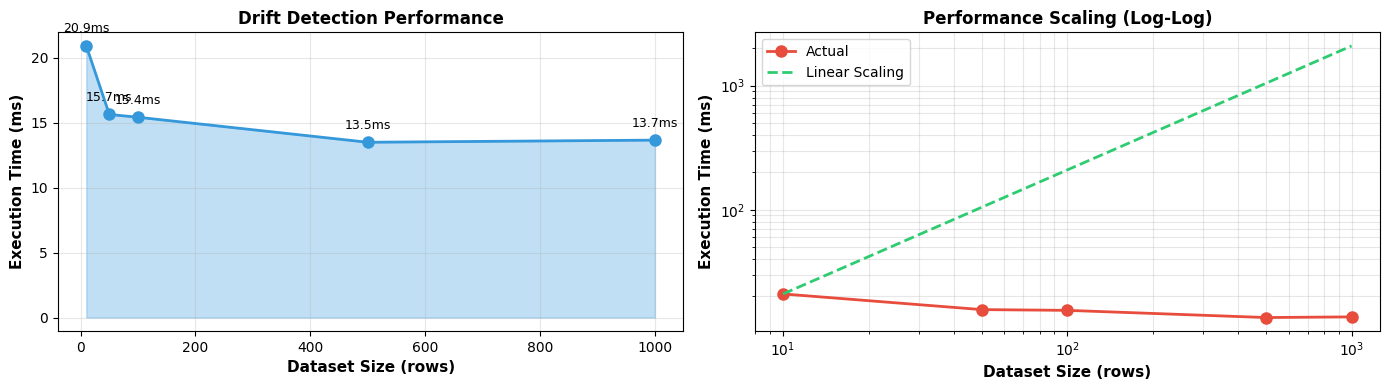


Performance scales approximately linearly with dataset size
Processing speed: ~13.67 μs per row


In [12]:
# Performance benchmarking
print("=" * 70)
print("PERFORMANCE BENCHMARKING")
print("=" * 70)

# Test with different dataset sizes
test_sizes = [10, 50, 100, 500, 1000]
results = []

for size in test_sizes:
    # Create test dataset
    test_data = drifted_df.sample(n=min(size, len(drifted_df)), replace=True).reset_index(drop=True)
    
    # Measure execution time
    start_time = time.time()
    report = detector.detect_drift(test_data)
    elapsed_time = time.time() - start_time
    
    results.append({
        'size': size,
        'time_ms': elapsed_time * 1000,
        'status': report['overall_status']
    })
    
    print(f"Dataset size: {size:>5} rows | Time: {elapsed_time*1000:>7.2f} ms | Status: {report['overall_status']}")

# Visualize performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Execution time
sizes = [r['size'] for r in results]
times = [r['time_ms'] for r in results]

ax1.plot(sizes, times, marker='o', linewidth=2, markersize=8, color='#3498db')
ax1.set_xlabel('Dataset Size (rows)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Execution Time (ms)', fontsize=11, fontweight='bold')
ax1.set_title('Drift Detection Performance', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.fill_between(sizes, times, alpha=0.3, color='#3498db')

for x, y in zip(sizes, times):
    ax1.text(x, y + max(times)*0.05, f'{y:.1f}ms', ha='center', fontsize=9)

# Plot 2: Log scale comparison
ax2.loglog(sizes, times, marker='o', linewidth=2, markersize=8, color='#e74c3c', label='Actual')

first_time = times[0]
linear_times = [first_time * (size / sizes[0]) for size in sizes]
ax2.loglog(sizes, linear_times, linestyle='--', linewidth=2, color='#2ecc71', label='Linear Scaling')

ax2.set_xlabel('Dataset Size (rows)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Execution Time (ms)', fontsize=11, fontweight='bold')
ax2.set_title('Performance Scaling (Log-Log)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Performance scales approximately linearly with dataset size")
print(f"Processing speed: ~{results[-1]['time_ms'] / results[-1]['size'] * 1000:.2f} μs per row")
print("=" * 70)

---
# 6. SUMMARY TABLE: Feature Comparison

In [13]:
# Create comprehensive comparison table
comparison_data = []

# Numeric features
for feature in baseline_report['numeric_features'].keys():
    base_info = baseline_report['numeric_features'][feature]
    drift_info = drifted_report['numeric_features'][feature]
    
    if 'z_score' in base_info:
        comparison_data.append({
            'Feature': feature,
            'Type': 'Numeric',
            'Baseline Severity': base_info['severity'],
            'Drifted Severity': drift_info['severity'],
            'Z-Score (Drifted)': round(drift_info['z_score'], 2),
            'Mean Shift': f"{drift_info['mean_shift']:.2f}"
        })

# Categorical features
for feature in baseline_report['categorical_features'].keys():
    base_info = baseline_report['categorical_features'][feature]
    drift_info = drifted_report['categorical_features'][feature]
    
    if 'max_proportion_shift' in base_info:
        comparison_data.append({
            'Feature': feature,
            'Type': 'Categorical',
            'Baseline Severity': base_info['severity'],
            'Drifted Severity': drift_info['severity'],
            'Max Shift': f"{drift_info['max_proportion_shift']:.1%}",
            'New Categories': len(drift_info['new_categories']) if drift_info['new_categories'] else 0
        })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "=" * 120)
print("COMPREHENSIVE FEATURE ANALYSIS: BASELINE vs DRIFTED DATA")
print("=" * 120)
print(comparison_df.to_string(index=False))
print("=" * 120)

# Summary
print("\nSUMMARY STATISTICS:")
print("-" * 50)
print(f"Total Features: {len(comparison_df)}")
print(f"  Numeric: {(comparison_df['Type'] == 'Numeric').sum()}")
print(f"  Categorical: {(comparison_df['Type'] == 'Categorical').sum()}")
print()
print(f"Baseline Dataset:")
print(f"  Overall Status: {baseline_report['overall_status']}")
print(f"  Total Features: {len(all_features)}")
print()
print(f"Drifted Dataset:")
print(f"  Overall Status: {drifted_report['overall_status']}")
print(f"  High Severity Features: {drifted_report['summary']['high_severity']}")
print(f"  Medium Severity Features: {drifted_report['summary']['medium_severity']}")
print("-" * 50)

print("\n✅ Analysis Complete! Significant drift detected across multiple features.")


COMPREHENSIVE FEATURE ANALYSIS: BASELINE vs DRIFTED DATA
         Feature        Type Baseline Severity Drifted Severity  Z-Score (Drifted) Mean Shift Max Shift  New Categories
   SeniorCitizen     Numeric               LOW           MEDIUM               1.73       0.64       NaN             NaN
          tenure     Numeric               LOW           MEDIUM               1.27     -31.06       NaN             NaN
  MonthlyCharges     Numeric               LOW           MEDIUM               1.19      35.72       NaN             NaN
    TotalCharges     Numeric               LOW              LOW               0.94   -2150.75       NaN             NaN
          gender Categorical               LOW           MEDIUM                NaN        NaN     20.2%             0.0
         Partner Categorical               LOW           MEDIUM                NaN        NaN     28.6%             0.0
      Dependents Categorical               LOW           MEDIUM                NaN        NaN     20.0